In [1]:
from jax import config
config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.random as jr

%load_ext autoreload
%autoreload 1

%aimport tensordev.kernel.free
%aimport tensordev.kernel.higher_order

from tensordev.kernel.free import free_kernel
from tensordev.kernel.higher_order import higher_order_kernel

import torch
from sigkernel import SigKernel, LinearKernel
salvi = SigKernel(LinearKernel(), dyadic_order=0, _naive_solver=True)

In [11]:
SEED = 2404029296
DIM = 2
N_FINE = 2 ** 12
DEGREES = [1, 2, 3, 4]
K_VALUES = list(range(4+2, 12))  # block sizes = 2^k, mesh size = 2^k / N_FINE
N_PAIRS = 10
HORIZON = 1.0


def sample_bm_paths(key, *, n_pairs, n_steps, dim, horizon=1.0):
    dt = horizon / n_steps
    kx, ky = jr.split(key)

    dX = jnp.sqrt(dt) * jr.normal(kx, (n_pairs, n_steps, dim), dtype=jnp.float64)
    dY = jnp.sqrt(dt) * jr.normal(ky, (n_pairs, n_steps, dim), dtype=jnp.float64)

    x0 = jnp.zeros((n_pairs, 1, dim), dtype=jnp.float64)
    y0 = jnp.zeros((n_pairs, 1, dim), dtype=jnp.float64)

    X = jnp.concatenate([x0, jnp.cumsum(dX, axis=1)], axis=1)
    Y = jnp.concatenate([y0, jnp.cumsum(dY, axis=1)], axis=1)
    return X, Y


key = jr.PRNGKey(SEED)
X, Y = sample_bm_paths(
    key,
    n_pairs=N_PAIRS,
    n_steps=N_FINE,
    dim=DIM,
    horizon=HORIZON,
)

# Fine reference: degree-1 piecewise linear approximation on the fine grid
dX = (jnp.diff(X, axis=-2),)
dY = (jnp.diff(Y, axis=-2),)

fine_vals = np.asarray(
    free_kernel(dX, dY, evaluate="terminal", return_fg=False, pairwise=False,backend="scan", dyadic_order=2,
                increment_in=True)
)
#fine_vals = salvi.compute_kernel(torch.Tensor(X), torch.Tensor(Y))

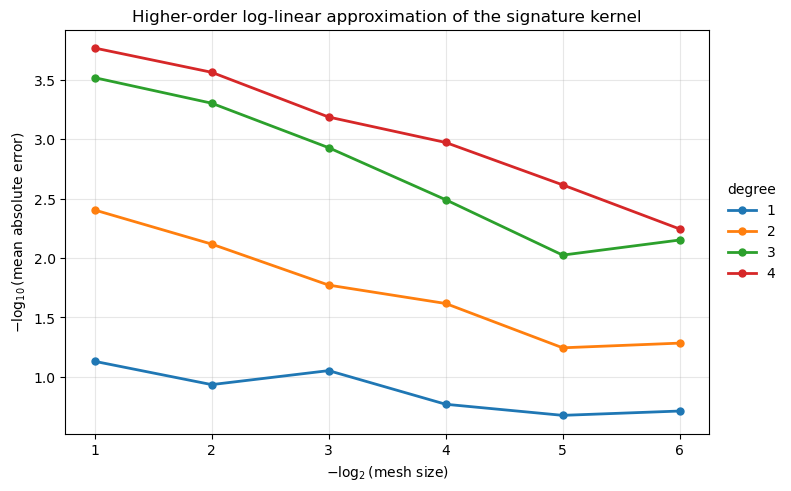

degree 1:
  -log2(mesh)=  1.0   mean_error=7.403593e-02
  -log2(mesh)=  2.0   mean_error=1.162792e-01
  -log2(mesh)=  3.0   mean_error=8.865347e-02
  -log2(mesh)=  4.0   mean_error=1.701591e-01
  -log2(mesh)=  5.0   mean_error=2.109702e-01
  -log2(mesh)=  6.0   mean_error=1.939928e-01

degree 2:
  -log2(mesh)=  1.0   mean_error=3.942842e-03
  -log2(mesh)=  2.0   mean_error=7.633453e-03
  -log2(mesh)=  3.0   mean_error=1.690275e-02
  -log2(mesh)=  4.0   mean_error=2.413653e-02
  -log2(mesh)=  5.0   mean_error=5.697475e-02
  -log2(mesh)=  6.0   mean_error=5.203026e-02

degree 3:
  -log2(mesh)=  1.0   mean_error=3.033971e-04
  -log2(mesh)=  2.0   mean_error=4.976263e-04
  -log2(mesh)=  3.0   mean_error=1.178673e-03
  -log2(mesh)=  4.0   mean_error=3.230416e-03
  -log2(mesh)=  5.0   mean_error=9.450264e-03
  -log2(mesh)=  6.0   mean_error=7.053271e-03

degree 4:
  -log2(mesh)=  1.0   mean_error=1.708378e-04
  -log2(mesh)=  2.0   mean_error=2.733958e-04
  -log2(mesh)=  3.0   mean_error=6.50

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

mean_errors = {n: [] for n in DEGREES}
all_errors = {n: [] for n in DEGREES}

# Paper-style axes:
# x = -log2(mesh size), mesh size = 2^k / N_FINE
# y = -log10(mean absolute error)
hvals = np.array([(2 ** k) / N_FINE for k in K_VALUES], dtype=float)
xvals = -np.log2(hvals)

def render_progress():
    clear_output(wait=True)
    print("Mean absolute errors")

    fig, ax = plt.subplots(figsize=(7.8, 4.8), constrained_layout=True)

    for n in DEGREES:
        if not mean_errors[n]:
            continue

        # x-values corresponding to the results computed so far for this degree
        xcurr = xvals[:len(mean_errors[n])]
        ecurr = np.array(mean_errors[n], dtype=float)

        # sort for plotting, in case xvals are not already monotone
        idx = np.argsort(xcurr)
        xplot = xcurr[idx]
        yplot = -np.log10(np.maximum(ecurr[idx], 1e-300))

        ax.plot(
            xplot,
            yplot,
            marker="o",
            linewidth=2,
            markersize=5,
            label=f"{n}",
        )

    ax.set_xlabel(r"$-\log_2(\mathrm{mesh\ size})$")
    ax.set_ylabel(r"$-\log_{10}(\mathrm{mean\ absolute\ error})$")
    ax.set_title("Higher-order log-linear approximation of the signature kernel")
    ax.grid(True, alpha=0.3)

    ax.legend(
        title="degree",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=False,
    )

    display(fig)
    plt.close(fig)

    # Progress table
    for n in DEGREES:
        if not mean_errors[n]:
            continue

        xcurr = xvals[:len(mean_errors[n])]
        ecurr = np.array(mean_errors[n], dtype=float)
        idx = np.argsort(xcurr)

        print(f"degree {n}:")
        for x, e in zip(xcurr[idx], ecurr[idx]):
            print(f"  -log2(mesh)={x:5.1f}   mean_error={e:.6e}")
        print()

# Initial empty frame
render_progress()

for n in DEGREES:
    for k in K_VALUES[::-1]:
        block_size = 2 ** k

        approx_vals = np.asarray(
            higher_order_kernel(
                X,
                Y,
                log_steps=(block_size, block_size),
                log_degree=(n, n),
                evaluate="terminal",
                return_fg=False,
                pairwise=False,
                backend="scan",
                dyadic_order=2,
                increment_input=False,
            )
        )

        errs = np.abs(approx_vals - fine_vals)
        all_errors[n].append(errs)
        mean_errors[n].append(float(np.mean(errs)))

        # Refresh after each new point
        render_progress()

# Final sorted arrays, if you still want them afterwards
order = np.argsort(xvals)
xplot = xvals[order]

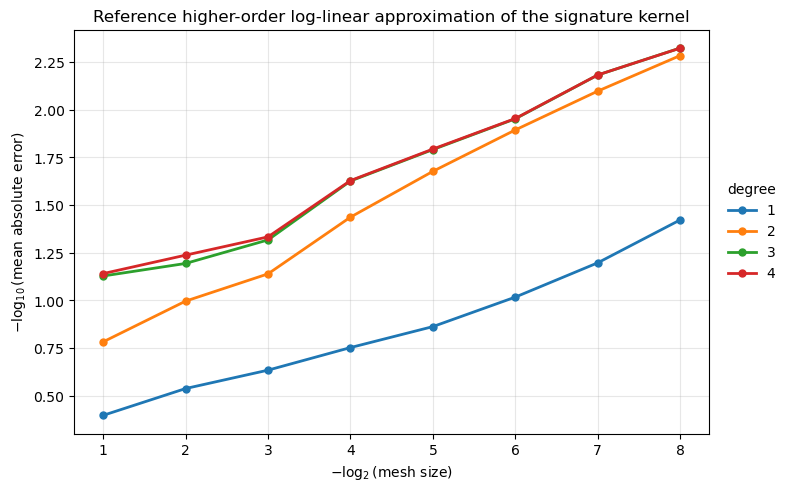

Mean absolute errors
degree 1:
  -log2(mesh)=  1.0   mean_error=4.007948e-01
  -log2(mesh)=  2.0   mean_error=2.899432e-01
  -log2(mesh)=  3.0   mean_error=2.321954e-01
  -log2(mesh)=  4.0   mean_error=1.767725e-01
  -log2(mesh)=  5.0   mean_error=1.372043e-01
  -log2(mesh)=  6.0   mean_error=9.605844e-02
  -log2(mesh)=  7.0   mean_error=6.348546e-02
  -log2(mesh)=  8.0   mean_error=3.780612e-02

degree 2:
  -log2(mesh)=  1.0   mean_error=1.649736e-01
  -log2(mesh)=  2.0   mean_error=1.008790e-01
  -log2(mesh)=  3.0   mean_error=7.256844e-02
  -log2(mesh)=  4.0   mean_error=3.658307e-02
  -log2(mesh)=  5.0   mean_error=2.103566e-02
  -log2(mesh)=  6.0   mean_error=1.275657e-02
  -log2(mesh)=  7.0   mean_error=7.982523e-03
  -log2(mesh)=  8.0   mean_error=5.195310e-03

degree 3:
  -log2(mesh)=  1.0   mean_error=7.446360e-02
  -log2(mesh)=  2.0   mean_error=6.399959e-02
  -log2(mesh)=  3.0   mean_error=4.816086e-02
  -log2(mesh)=  4.0   mean_error=2.364360e-02
  -log2(mesh)=  5.0   mean_

In [5]:
import sys
from pathlib import Path

# ------------------------------------------------------------------
# external reference package
# notebook assumed to live in: tensordev/notebooks
# ------------------------------------------------------------------
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent.parent
REF_ROOT = REPO_ROOT / "high-order-sigkernel"

if str(REF_ROOT) not in sys.path:
    sys.path.insert(0, str(REF_ROOT))

from src.roughsigkernel import GoursatSolver
from src.utils import PAB, Sig

SEED = 240402926
DIM = 2
N_FINE = 2 ** 12
DEGREES = [1, 2, 3, 4]
K_VALUES = list(range(4, 12))
N_PAIRS = 100
HORIZON = 1.0


def reference_terminal_kernel_single(x, y, *, log_steps, degree, dyadic_order=0):
    x_np = np.asarray(x, dtype=np.float64)
    y_np = np.asarray(y, dtype=np.float64)

    x_pab = PAB(x_np, step=log_steps, m=degree)
    y_pab = PAB(y_np, step=log_steps, m=degree)

    s_x = Sig(x_np, step=log_steps, m=degree)
    s_y = Sig(y_np, step=log_steps, m=degree)

    refine = 2 ** dyadic_order

    solver = GoursatSolver()
    adj_x_y, _ = solver.integrate(x_pab, y_pab, s_x, s_y, refine=refine)

    return float(adj_x_y[-1, -1, 0])


def reference_terminal_kernel_batch(X, Y, *, log_steps, degree, dyadic_order=0):
    vals = []
    for i in range(X.shape[0]):
        vals.append(
            reference_terminal_kernel_single(
                X[i],
                Y[i],
                log_steps=log_steps,
                degree=degree,
                dyadic_order=dyadic_order,
            )
        )
    return np.asarray(vals, dtype=np.float64)


mean_errors = {n: [] for n in DEGREES}
all_errors = {n: [] for n in DEGREES}

for n in DEGREES:
    for k in K_VALUES:
        block_size = 2 ** k

        approx_vals = reference_terminal_kernel_batch(
            X,
            Y,
            log_steps=block_size,
            degree=n,
            dyadic_order=1,
        )

        errs = np.abs(approx_vals - fine_vals)
        all_errors[n].append(errs)
        mean_errors[n].append(float(np.mean(errs)))

hvals = np.array([(2 ** k) / N_FINE for k in K_VALUES], dtype=float)
xvals = -np.log2(hvals)
order = np.argsort(xvals)
xplot = xvals[order]

fig, ax = plt.subplots(figsize=(7.8, 4.8), constrained_layout=True)

for n in DEGREES:
    errs = np.array(mean_errors[n])[order]
    yplot = -np.log10(np.maximum(errs, 1e-300))
    ax.plot(xplot, yplot, marker="o", linewidth=2, markersize=5, label=f"{n}")

ax.set_xlabel(r"$-\log_2(\mathrm{mesh\ size})$")
ax.set_ylabel(r"$-\log_{10}(\mathrm{mean\ absolute\ error})$")
ax.set_title("Reference higher-order log-linear approximation of the signature kernel")
ax.grid(True, alpha=0.3)

ax.legend(
    title="degree",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=False,
)

plt.show()

print("Mean absolute errors")
for n in DEGREES:
    vals = np.array(mean_errors[n])[order]
    print(f"degree {n}:")
    for x, e in zip(xplot, vals):
        print(f"  -log2(mesh)={x:5.1f}   mean_error={e:.6e}")
    print()

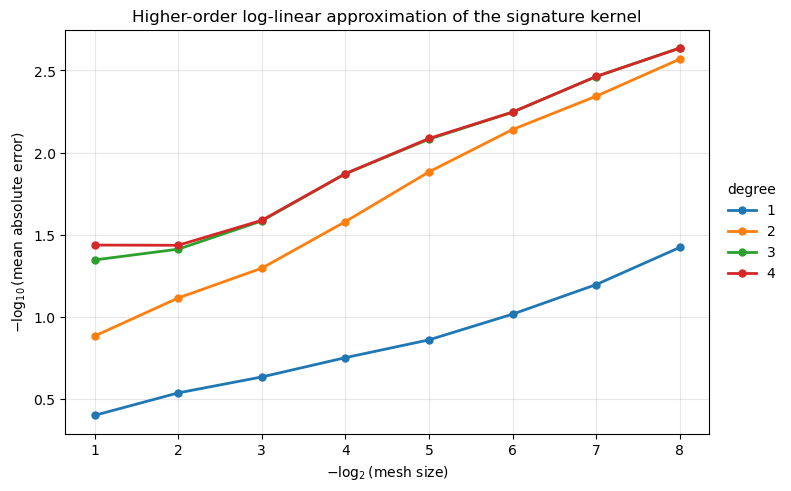

Mean absolute errors
degree 1:
  -log2(mesh)=  1.0   mean_error=3.966459e-01
  -log2(mesh)=  2.0   mean_error=2.895198e-01
  -log2(mesh)=  3.0   mean_error=2.316036e-01
  -log2(mesh)=  4.0   mean_error=1.767298e-01
  -log2(mesh)=  5.0   mean_error=1.377575e-01
  -log2(mesh)=  6.0   mean_error=9.609046e-02
  -log2(mesh)=  7.0   mean_error=6.351436e-02
  -log2(mesh)=  8.0   mean_error=3.773773e-02

degree 2:
  -log2(mesh)=  1.0   mean_error=1.304859e-01
  -log2(mesh)=  2.0   mean_error=7.661053e-02
  -log2(mesh)=  3.0   mean_error=5.046862e-02
  -log2(mesh)=  4.0   mean_error=2.628228e-02
  -log2(mesh)=  5.0   mean_error=1.309187e-02
  -log2(mesh)=  6.0   mean_error=7.232218e-03
  -log2(mesh)=  7.0   mean_error=4.536142e-03
  -log2(mesh)=  8.0   mean_error=2.697688e-03

degree 3:
  -log2(mesh)=  1.0   mean_error=4.494737e-02
  -log2(mesh)=  2.0   mean_error=3.864961e-02
  -log2(mesh)=  3.0   mean_error=2.600911e-02
  -log2(mesh)=  4.0   mean_error=1.343369e-02
  -log2(mesh)=  5.0   mean_

In [1]:
# --- piecewise log-linear kernel diagnostic on Brownian paths ---
# Includes a zero-padding diagnostic for the higher-order PDE solver.

from jax import config

config.update("jax_enable_x64", True)

import sys
from pathlib import Path
import numpy as np
import jax.numpy as jnp
import jax.random as jr

repo_root = Path("/mnt/data/tensordev_unzipped/tensordev")
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.append(str(src_root))

from tensordev import Jax
from tensordev.kernel.free import free_kernel

core = Jax()


# ----------------------------
# helpers
# ----------------------------
def sample_brownian_paths(key, *, batch, n_intervals, dim, T=1.0, dtype=jnp.float64):
    """
    Sample standard d-dimensional Brownian motion on a uniform grid with n_intervals.
    Returns a path of shape (batch, n_intervals + 1, dim).
    """
    dt = dtype(T) / n_intervals
    dB = jnp.sqrt(dt) * jr.normal(key, shape=(batch, n_intervals, dim), dtype=dtype)
    X = jnp.concatenate(
        [jnp.zeros((batch, 1, dim), dtype=dtype), jnp.cumsum(dB, axis=1)],
        axis=1,
    )
    return X


def path_to_increments(path_levels):
    """
    DenseElemFirstOn path -> interval increments.
    """
    return tuple(jnp.diff(level, axis=-2) for level in path_levels)


def broadcast_pairwise_levels(x, y):
    """
    Same broadcasting convention as in tests/kernel/test_free_kernel.py.
    """
    batch_x = x[0].shape[:-1]
    batch_y = y[0].shape[:-1]
    nx = len(batch_x)
    ny = len(batch_y)

    x_bc = tuple(level.reshape(batch_x + (1,) * ny + level.shape[-1:]) for level in x)
    y_bc = tuple(level.reshape((1,) * nx + batch_y + level.shape[-1:]) for level in y)
    return x_bc, y_bc


def pairwise_inner_products(dev_x, dev_y, *, core):
    """
    Pairwise inner products of two batches of graded elements.
    """
    dev_x_bc, dev_y_bc = broadcast_pairwise_levels(dev_x, dev_y)
    return np.asarray(core.tensor_inner_product(dev_x_bc, dev_y_bc))


def build_piecewise_loglinear_increments(dX, *, log_steps, log_degree, core):
    """
    This is exactly the approximation used in higher_order.py:
      - split increments into contiguous blocks of size log_steps
      - compute each block signature truncated at log_degree
      - take tensor logarithm
      - interpret those blockwise logs as increments of a new path
    """
    sig_blocks = core.tensor_development(
        dX,
        axis=-2,
        trunc=log_degree,
        block_size=log_steps,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )

    # tensor_development returns levels (0,1,...,log_degree), so drop level 0
    log_blocks = core.tensor_logarithm(
        sig_blocks[1:],
        trunc=log_degree,
        output_zero_level=False,
    )

    # If there is exactly one emitted block, reinsert a block axis so the result
    # is still interpreted as a path with one interval.
    n_blocks = dX[0].shape[-2] // log_steps
    if n_blocks == 1:
        log_blocks = tuple(level[..., None, :] for level in log_blocks)

    return log_blocks


def pad_zero_levels(levels, n_pad=1):
    """
    Pad a graded path/increment tuple with n_pad extra zero levels.
    The new levels have the same batch/block axes and the expected tensor width d^(k).
    """
    if n_pad <= 0:
        return tuple(levels)

    out = list(levels)
    d = levels[0].shape[-1]  # width of level 1
    batch_block_shape = levels[0].shape[:-1]

    for k in range(len(levels) + 1, len(levels) + n_pad + 1):
        width = d ** k
        out.append(jnp.zeros(batch_block_shape + (width,), dtype=levels[0].dtype))

    return tuple(out)


# ----------------------------
# parameters
# ----------------------------
batch_x = 8
batch_y = 8
dim = 2
n_intervals = 2 ** 8
T = 1.0

kernel_trunc = 10
log_steps = 2
log_degrees = range(1, kernel_trunc + 1)

assert n_intervals % log_steps == 0, "log_steps must divide n_intervals"

# ----------------------------
# sample Brownian paths
# ----------------------------
key = jr.PRNGKey(0)
key_x, key_y = jr.split(key)

X = sample_brownian_paths(key_x, batch=batch_x, n_intervals=n_intervals, dim=dim, T=T)
Y = sample_brownian_paths(key_y, batch=batch_y, n_intervals=n_intervals, dim=dim, T=T)

# level-1 only paths
X_levels = (X,)
Y_levels = (Y,)

# fine-grid increments
dX = path_to_increments(X_levels)
dY = path_to_increments(Y_levels)

# ----------------------------
# fine reference: inner product of full developments
# ----------------------------
ref_dev_x = core.tensor_development(
    dX,
    axis=-2,
    trunc=kernel_trunc,
    accumulate=False,
    output_starting_point=False,
    increment_input=True,
)
ref_dev_y = core.tensor_development(
    dY,
    axis=-2,
    trunc=kernel_trunc,
    accumulate=False,
    output_starting_point=False,
    increment_input=True,
)
ref_ip = pairwise_inner_products(ref_dev_x, ref_dev_y, core=core)

# optional cross-check: for level-1 inputs, free_kernel should match this
ref_kernel = np.asarray(
    free_kernel(dX, dY, evaluate="terminal", return_fg=False, pairwise=True, backend="scan", dyadic_order=0, core=core,
                increment_in=True)
)
print("fine-grid check: max |free_kernel - development inner product| =",
      float(np.max(np.abs(ref_kernel - ref_ip))))



fine-grid check: max |free_kernel - development inner product| = 0.005924916969213712


In [ ]:

# ----------------------------
# piecewise log-linear approximations with log_steps = 2
# ----------------------------
rows = []
padding_rows = []

approx_ip_by_degree = {}
approx_kernel_by_degree = {}

ref_norm = np.linalg.norm(ref_ip)

for log_degree in log_degrees:
    log_x = build_piecewise_loglinear_increments(
        dX, log_steps=log_steps, log_degree=log_degree, core=core
    )
    log_y = build_piecewise_loglinear_increments(
        dY, log_steps=log_steps, log_degree=log_degree, core=core
    )

    # inner product of developments of the log-linear paths
    dev_log_x = core.tensor_development(
        log_x,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    dev_log_y = core.tensor_development(
        log_y,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    approx_ip = pairwise_inner_products(dev_log_x, dev_log_y, core=core)

    # higher-order free kernel on those log increments
    approx_kernel = np.asarray(
        free_kernel(log_x, log_y, evaluate="terminal", return_fg=False, pairwise=True, backend="scan", dyadic_order=0,
                    core=core, increment_in=True)
    )

    approx_ip_by_degree[log_degree] = approx_ip
    approx_kernel_by_degree[log_degree] = approx_kernel

    diff = approx_ip - ref_ip
    fro_err = float(np.linalg.norm(diff))
    rel_fro_err = fro_err / ref_norm if ref_norm > 0 else np.nan
    max_abs_err = float(np.max(np.abs(diff)))
    kernel_inner_mismatch = float(np.max(np.abs(approx_kernel - approx_ip)))

    rows.append(
        (
            log_degree,
            int(log_x[0].shape[-2]),
            fro_err,
            rel_fro_err,
            max_abs_err,
            kernel_inner_mismatch,
        )
    )

    # ----------------------------
    # zero-padding diagnostic
    # ----------------------------
    log_x_pad1 = pad_zero_levels(log_x, 1)
    log_y_pad1 = pad_zero_levels(log_y, 1)
    log_x_pad2 = pad_zero_levels(log_x, 2)
    log_y_pad2 = pad_zero_levels(log_y, 2)

    dev_log_x_pad1 = core.tensor_development(
        log_x_pad1,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    dev_log_y_pad1 = core.tensor_development(
        log_y_pad1,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    approx_ip_pad1 = pairwise_inner_products(dev_log_x_pad1, dev_log_y_pad1, core=core)

    dev_log_x_pad2 = core.tensor_development(
        log_x_pad2,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    dev_log_y_pad2 = core.tensor_development(
        log_y_pad2,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    approx_ip_pad2 = pairwise_inner_products(dev_log_x_pad2, dev_log_y_pad2, core=core)

    approx_kernel_pad1 = np.asarray(
        free_kernel(log_x_pad1, log_y_pad1, evaluate="terminal", return_fg=False, pairwise=True, backend="scan",
                    dyadic_order=0, core=core, increment_in=True)
    )
    approx_kernel_pad2 = np.asarray(
        free_kernel(log_x_pad2, log_y_pad2, evaluate="terminal", return_fg=False, pairwise=True, backend="scan",
                    dyadic_order=0, core=core, increment_in=True)
    )

    padding_rows.append(
        (
            log_degree,
            len(log_x),
            float(np.max(np.abs(approx_ip_pad1 - approx_ip))),
            float(np.max(np.abs(approx_kernel_pad1 - approx_kernel))),
            float(np.max(np.abs(approx_kernel_pad1 - approx_ip_pad1))),
            float(np.max(np.abs(approx_ip_pad2 - approx_ip))),
            float(np.max(np.abs(approx_kernel_pad2 - approx_kernel))),
            float(np.max(np.abs(approx_kernel_pad2 - approx_ip_pad2))),
        )
    )

# ----------------------------
# print main table
# ----------------------------
header = (
    f"{'deg':>3}  {'n_blocks':>8}  {'fro_err':>14}  "
    f"{'rel_fro_err':>14}  {'max_abs_err':>14}  {'|kernel-inner|_max':>18}"
)
print()
print(header)
print("-" * len(header))
for deg, n_blocks, fro_err, rel_fro_err, max_abs_err, kernel_inner_mismatch in rows:
    print(
        f"{deg:3d}  {n_blocks:8d}  {fro_err:14.6e}  "
        f"{rel_fro_err:14.6e}  {max_abs_err:14.6e}  {kernel_inner_mismatch:18.6e}"
    )

best = min(rows, key=lambda r: r[3])
print("\nbest degree by relative Frobenius error:")
print(
    f"log_degree={best[0]}, n_blocks={best[1]}, "
    f"fro_err={best[2]:.6e}, rel_fro_err={best[3]:.6e}, max_abs_err={best[4]:.6e}"
)

# ----------------------------
# print padding sensitivity table
# ----------------------------
pad_header = (
    f"{'deg':>3}  {'lev':>3}  "
    f"{'|ip(pad1)-ip|_max':>18}  {'|k(pad1)-k|_max':>18}  {'|k1-ip1|_max':>16}  "
    f"{'|ip(pad2)-ip|_max':>18}  {'|k(pad2)-k|_max':>18}  {'|k2-ip2|_max':>16}"
)
print()
print("zero-padding diagnostic")
print(pad_header)
print("-" * len(pad_header))
for row in padding_rows:
    deg, lev, ip1_shift, k1_shift, k1_mis, ip2_shift, k2_shift, k2_mis = row
    print(
        f"{deg:3d}  {lev:3d}  "
        f"{ip1_shift:18.6e}  {k1_shift:18.6e}  {k1_mis:16.6e}  "
        f"{ip2_shift:18.6e}  {k2_shift:18.6e}  {k2_mis:16.6e}"
    )

# keep these around for inspection
results = rows
padding_results = padding_rows
reference_inner_product = ref_ip

In [3]:
# --- compare degree-1 vs degree-1 padded-with-zero-level, against benchmark ---

import numpy as np
import jax.numpy as jnp


def pad_zero_levels(levels, n_pad=1):
    out = list(levels)
    d = levels[0].shape[-1]  # level-1 width
    batch_block_shape = levels[0].shape[:-1]
    for k in range(len(levels) + 1, len(levels) + n_pad + 1):
        out.append(jnp.zeros(batch_block_shape + (d ** k,), dtype=levels[0].dtype))
    return tuple(out)


# build degree-1 piecewise log-linear increments
log_degree = 1

log_x_1 = build_piecewise_loglinear_increments(
    dX, log_steps=log_steps, log_degree=log_degree, core=core
)
log_y_1 = build_piecewise_loglinear_increments(
    dY, log_steps=log_steps, log_degree=log_degree, core=core
)

# pad with one zero top level
log_x_1_pad = pad_zero_levels(log_x_1, 1)
log_y_1_pad = pad_zero_levels(log_y_1, 1)

# benchmark: inner product of developments
dev_x_1 = core.tensor_development(
    log_x_1,
    axis=-2,
    trunc=kernel_trunc,
    accumulate=False,
    output_starting_point=False,
    increment_input=True,
)
dev_y_1 = core.tensor_development(
    log_y_1,
    axis=-2,
    trunc=kernel_trunc,
    accumulate=False,
    output_starting_point=False,
    increment_input=True,
)
bench_1 = pairwise_inner_products(dev_x_1, dev_y_1, core=core)

# same benchmark after padding (should be unchanged)
dev_x_1_pad = core.tensor_development(
    log_x_1_pad,
    axis=-2,
    trunc=kernel_trunc,
    accumulate=False,
    output_starting_point=False,
    increment_input=True,
)
dev_y_1_pad = core.tensor_development(
    log_y_1_pad,
    axis=-2,
    trunc=kernel_trunc,
    accumulate=False,
    output_starting_point=False,
    increment_input=True,
)
bench_1_pad = pairwise_inner_products(dev_x_1_pad, dev_y_1_pad, core=core)

# free-kernel values
k_1 = np.asarray(
    free_kernel(log_x_1, log_y_1, evaluate="terminal", return_fg=False, pairwise=True, backend="scan", dyadic_order=0,
                core=core, increment_in=True)
)

k_1_pad = np.asarray(
    free_kernel(log_x_1_pad, log_y_1_pad, evaluate="terminal", return_fg=False, pairwise=True, backend="scan",
                dyadic_order=0, core=core, increment_in=True)
)

print("degree-1 consistency check")
print("--------------------------")
print("n_levels(unpadded) =", len(log_x_1))
print("n_levels(padded)   =", len(log_x_1_pad))
print()

print("max |benchmark(padded) - benchmark|      =",
      float(np.max(np.abs(bench_1_pad - bench_1))))
print("max |kernel(deg1) - kernel(deg1 padded)| =",
      float(np.max(np.abs(k_1 - k_1_pad))))
print("max |kernel(deg1) - benchmark|           =",
      float(np.max(np.abs(k_1 - bench_1))))
print("max |kernel(deg1 padded) - benchmark|    =",
      float(np.max(np.abs(k_1_pad - bench_1))))
print("max |kernel(deg1 padded) - benchmark(pad)| =",
      float(np.max(np.abs(k_1_pad - bench_1_pad))))

# optional: show a few representative entries
flat_k1 = k_1.reshape(-1)
flat_k1p = k_1_pad.reshape(-1)
flat_b = bench_1.reshape(-1)

print("\nfirst 5 entries:")
for i in range(min(5, flat_k1.shape[0])):
    print(
        f"{i:2d}: "
        f"k_deg1={flat_k1[i]: .12f}   "
        f"k_deg1_pad={flat_k1p[i]: .12f}   "
        f"bench={flat_b[i]: .12f}"
    )

degree-1 consistency check
--------------------------
n_levels(unpadded) = 1
n_levels(padded)   = 2

max |benchmark(padded) - benchmark|      = 1.1796119636642288e-15
max |kernel(deg1) - kernel(deg1 padded)| = 8.704148513061227e-14
max |kernel(deg1) - benchmark|           = 0.022263879386417607
max |kernel(deg1 padded) - benchmark|    = 0.0222638793864931
max |kernel(deg1 padded) - benchmark(pad)| = 0.022263879386492658

first 5 entries:
 0: k_deg1=-0.815467128593   k_deg1_pad=-0.815467128593   bench=-0.821548123505
 1: k_deg1= 2.719749541149   k_deg1_pad= 2.719749541149   bench= 2.731375298832
 2: k_deg1=-0.030967336145   k_deg1_pad=-0.030967336145   bench=-0.032099897647
 3: k_deg1= 5.347441598240   k_deg1_pad= 5.347441598240   bench= 5.360209271475
 4: k_deg1= 2.737157502664   k_deg1_pad= 2.737157502664   bench= 2.739222767114


In [1]:
# Diagnostic: is the problem the higher-order PDE discretization?
# Assumes the helpers from the previous cell are already defined:
#   - dX, dY
#   - kernel_trunc
#   - log_steps
#   - build_piecewise_loglinear_increments
#   - pairwise_inner_products
#   - core
# and imports/free_kernel already exist.

import numpy as np

DYADICS = [0, 1, 2, 3, 4]
LOG_DEGREES = range(1, kernel_trunc + 1)

print("fine-grid level-1: free_kernel(dx,dy) vs development inner product")
ref_dev_x = core.tensor_development(
    dX,
    axis=-2,
    trunc=kernel_trunc,
    accumulate=False,
    output_starting_point=False,
    increment_input=True,
)
ref_dev_y = core.tensor_development(
    dY,
    axis=-2,
    trunc=kernel_trunc,
    accumulate=False,
    output_starting_point=False,
    increment_input=True,
)
ref_ip_fine = pairwise_inner_products(ref_dev_x, ref_dev_y, core=core)

for lam in DYADICS:
    fine_k = np.asarray(
        free_kernel(dX, dY, evaluate="terminal", return_fg=False, pairwise=True, backend="scan", dyadic_order=lam,
                    core=core, increment_in=True)
    )
    err = float(np.max(np.abs(fine_k - ref_ip_fine)))
    print(f"  dyadic_order={lam}: max error = {err:.6e}")

print("\nblockwise log-linear paths: free_kernel(log_x,log_y) vs development inner product")
header = f"{'deg':>3}  " + "  ".join([f"dy{lam:>1}" for lam in DYADICS])
print(header)
print("-" * len(header))

for log_degree in LOG_DEGREES:
    log_x = build_piecewise_loglinear_increments(
        dX, log_steps=log_steps, log_degree=log_degree, core=core
    )
    log_y = build_piecewise_loglinear_increments(
        dY, log_steps=log_steps, log_degree=log_degree, core=core
    )

    dev_log_x = core.tensor_development(
        log_x,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    dev_log_y = core.tensor_development(
        log_y,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    ref_ip = pairwise_inner_products(dev_log_x, dev_log_y, core=core)

    errs = []
    for lam in DYADICS:
        pde_val = np.asarray(
            free_kernel(log_x, log_y, evaluate="terminal", return_fg=False, pairwise=True, backend="scan",
                        dyadic_order=lam, core=core, increment_in=True)
        )
        errs.append(float(np.max(np.abs(pde_val - ref_ip))))

    print(f"{log_degree:3d}  " + "  ".join(f"{e:8.2e}" for e in errs))

NameError: name 'kernel_trunc' is not defined

In [21]:
len(log_x)

4

In [23]:
# single-pair diagnostic: is level 3 being used at all?

import numpy as np

# one pair only
dX1 = tuple(level[:1] for level in dX)
dY1 = tuple(level[:1] for level in dY)

log2_x = build_piecewise_loglinear_increments(dX1, log_steps=log_steps, log_degree=2, core=core)
log2_y = build_piecewise_loglinear_increments(dY1, log_steps=log_steps, log_degree=2, core=core)

log3_x = build_piecewise_loglinear_increments(dX1, log_steps=log_steps, log_degree=3, core=core)
log3_y = build_piecewise_loglinear_increments(dY1, log_steps=log_steps, log_degree=3, core=core)

print("max |level-3 log_x| =", float(np.max(np.abs(np.asarray(log3_x[2])))))
print("max |level-3 log_y| =", float(np.max(np.abs(np.asarray(log3_y[2])))))

for lam in [0, 1, 2, 3, 4]:
    k2 = float(np.asarray(
        free_kernel(log2_x, log2_y, evaluate="terminal", return_fg=False, pairwise=False, backend="scan",
                    dyadic_order=lam, core=core, increment_in=True)
    ).squeeze())

    k3 = float(np.asarray(
        free_kernel(log3_x, log3_y, evaluate="terminal", return_fg=False, pairwise=False, backend="scan",
                    dyadic_order=lam, core=core, increment_in=True)
    ).squeeze())

    print(f"dyadic_order={lam}:  k2={k2:.12f}  k3={k3:.12f}  |k3-k2|={abs(k3 - k2):.6e}")

max |level-3 log_x| = 0.0007030371608051846
max |level-3 log_y| = 0.0020674787943330843
dyadic_order=0:  k2=-1.046878106090  k3=-1.047581206011  |k3-k2|=7.030999e-04
dyadic_order=1:  k2=-0.858631457636  k3=-0.860190028523  |k3-k2|=1.558571e-03
dyadic_order=2:  k2=-0.790711529956  k3=-0.792784120991  |k3-k2|=2.072591e-03
dyadic_order=3:  k2=-0.757858115167  k3=-0.760222130973  |k3-k2|=2.364016e-03
dyadic_order=4:  k2=-0.740922220315  k3=-0.743442230928  |k3-k2|=2.520011e-03


In [2]:
import numpy as np

kernel_trunc = 10
log_degree = 3
log_steps_list = [2, 4, 8, 16]
dyadics = [0, 2, 4]

# single pair only
dX1 = tuple(level[:1] for level in dX)
dY1 = tuple(level[:1] for level in dY)

print(f"{'log_steps':>9}  {'n_blocks':>8}  " + "  ".join([f"dy{lam}" for lam in dyadics]))
print("-" * (24 + 12 * len(dyadics)))

for i, ls in enumerate(log_steps_list):
    if dX1[0].shape[-2] % ls != 0:
        continue

    log_x = build_piecewise_loglinear_increments(
        dX1, log_steps=ls, log_degree=log_degree + i, core=core
    )
    log_y = build_piecewise_loglinear_increments(
        dY1, log_steps=ls, log_degree=log_degree + i, core=core
    )

    dev_log_x = core.tensor_development(
        log_x,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    dev_log_y = core.tensor_development(
        log_y,
        axis=-2,
        trunc=kernel_trunc,
        accumulate=False,
        output_starting_point=False,
        increment_input=True,
    )
    ref_ip = float(np.asarray(core.tensor_inner_product(dev_log_x, dev_log_y)).squeeze())

    errs = []
    for lam in dyadics:
        val = float(np.asarray(
            free_kernel(log_x, log_y, evaluate="terminal", return_fg=False, pairwise=False, backend="scan",
                        dyadic_order=lam, core=core, increment_in=True)
        ).squeeze())
        errs.append(abs(val - ref_ip))

    print(f"{ls:9d}  {log_x[0].shape[-2]:8d}  " + "  ".join(f"{e:8.2e}" for e in errs))

log_steps  n_blocks  dy0  dy2  dy4
------------------------------------------------------------
        2       128  1.92e-02  1.84e-03  2.90e-04
        4        64  3.86e-02  5.43e-03  1.25e-03
        8        32  7.29e-02  1.09e-02  2.31e-03
       16        16  1.73e-01  3.42e-02  8.07e-03
